# Day 5 — Representation Learning & Embeddings

## Note 5.1 — What a representation is: from raw pixels to learned features

### How to read this note

Run the cells from top to bottom, in order. Read each text cell before you run the code cell under it, so you know what the code is about to show you.

Most code cells are short on purpose. Each one makes one object, or does one thing to it, and prints what comes back. Look at what comes back before you move on.

The blocks called **Questions to sit with** are places to stop and think. They are not tests. Try to answer them in your own words before reading on.

Every number written in the text of this note came from running this notebook on a CPU. If you run it on a different machine, a few numbers may differ in the last decimal place. Times (how many seconds a cell took) will differ more, because they depend on your machine.

This note stands alone. It downloads its own data and defines everything it uses. You do not need to have run any other notebook first.

### Learning goal and outcome

**Goal.** Understand what a *representation* is, and why the way we turn a raw input into numbers decides how well any model can use it.

**Outcome.** By the end of this note you can take a folder of photos, turn each photo into a list of numbers in four different ways (raw pixels, hand-made features, a CNN with random weights, a CNN trained on other photos), measure which list of numbers is most useful, and explain why.

### Objectives

By the end of this note you will be able to:

1. Say what a representation is, in one sentence, and give two different representations of the same photo.
2. Draw the pipeline *raw input → encoder → representation → task* and say what each box does.
3. Turn an image file into a tensor and read its shape.
4. Explain why raw pixels are a poor representation of a photo, using a measured example.
5. Check a difference between two representations photo by photo, with a sign test.
6. Build a small set of hand-made features and measure how far they get.
7. Explain what a convolution does, what a filter is, and why a CNN needs far fewer weights than a fully connected layer.
8. Use a pretrained CNN as a feature extractor and measure the gain over raw pixels.
9. Place CNNs, transfer learning, Vision Transformers and multimodal models on one simple timeline.

### Datasets used

**Beans** (validation and test splits only, 18.5 MB + 17.7 MB). Photos of bean plant leaves taken in fields in Uganda, in three classes: *angular leaf spot*, *bean rust* and *healthy*. We use 133 photos as our labelled reference set and 128 photos as our test photos.

Why this dataset: it is small enough to download quickly on a laptop, the photos are real field photos (messy backgrounds, different light), and — importantly — nothing like "bean leaf disease" appears in the big photo collection the pretrained network in Section 9 learned from. So when that network helps, it is helping on a task it has never seen.

**ResNet-18 weights** (46.8 MB). Not a dataset, but a download: the learned weights of a CNN trained on ImageNet. Section 9 explains both words.

### Table of contents

1. Where Day 4 left us
2. What a representation is
3. The pipeline: raw input → encoder → representation → task
4. Meet the images
5. Raw pixels as a representation
6. Hand-made features: the first idea people had
7. What a convolution does
8. A CNN with random weights
9. The same CNN after training on ImageNet
10. From hand-made features to Vision Transformers
11. What to take away

### Runtime budget

The times below are for a laptop CPU. Downloads depend on your internet speed.

| Part | What happens | Time |
|---|---|---|
| Setup | imports, version check | under 1 minute |
| Section 4 | download Beans (36 MB), load 261 photos | 1–2 minutes |
| Sections 5–7 | raw pixels, hand-made features, convolution | under 1 minute |
| Section 8 | random CNN on 261 photos | under 1 minute |
| Section 9 | download ResNet-18 (47 MB), features for 261 photos | 1–2 minutes |
| Whole note | | about 5 minutes of running, plus reading |

### Environment setup

This note was built with the versions below. If your versions are different, the note will most likely still run, but a few numbers may change slightly.

To install exactly these versions, remove the `#` at the start of the `%pip` line and run the cell once. Then restart the kernel (the Python process behind the notebook) so the new versions are loaded.

In [1]:
# Remove the "#" on the next line to install the pinned versions, then restart the kernel.
# %pip install torch==2.14.0 torchvision==0.29.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 matplotlib==3.10.8 pillow==12.1.1 scipy==1.17.1

The next cell checks what you actually have installed. `importlib.metadata.version` asks Python which version of a package is installed. We compare it with the pinned version and print `ok` or `DIFFERENT`.

In [2]:
import importlib.metadata as md

PINNED = {"torch": "2.14.0", "torchvision": "0.29.0", "scikit-learn": "1.8.0",
          "numpy": "2.4.4", "pandas": "3.0.2", "matplotlib": "3.10.8", "pillow": "12.1.1", "scipy": "1.17.1"}

for package, wanted in PINNED.items():
    installed = md.version(package)
    status = "ok" if installed.split("+")[0] == wanted else "DIFFERENT"
    print(f"{package:14} pinned {wanted:8} installed {installed:12} {status}")

torch          pinned 2.14.0   installed 2.14.0+cpu   ok
torchvision    pinned 0.29.0   installed 0.29.0+cpu   ok
scikit-learn   pinned 1.8.0    installed 1.8.0        ok
numpy          pinned 2.4.4    installed 2.4.4        ok
pandas         pinned 3.0.2    installed 3.0.2        ok
matplotlib     pinned 3.10.8   installed 3.10.8       ok
pillow         pinned 12.1.1   installed 12.1.1       ok
scipy          pinned 1.17.1   installed 1.17.1       ok


### Environment detection

PyTorch can run on three kinds of hardware: `cuda` (an NVIDIA graphics card), `mps` (the graphics part of an Apple Silicon Mac) or `cpu` (the normal processor). The next cell finds out which ones your machine has.

This note then chooses the **CPU on purpose**, on every machine. The work here is small enough for a CPU, and running on the CPU means your numbers will match the numbers written in this note. A graphics card would only make it a little faster.

In [3]:
import torch

if torch.cuda.is_available():
    FOUND = "cuda"
elif torch.backends.mps.is_available():
    FOUND = "mps"
else:
    FOUND = "cpu"

DEVICE = "cpu"   # chosen on purpose, see the text above
print("Best hardware found on this machine:", FOUND)
print("Hardware this note will use:        ", DEVICE)
print("CPU threads PyTorch can use:        ", torch.get_num_threads())

Best hardware found on this machine: cpu
Hardware this note will use:         cpu
CPU threads PyTorch can use:         1


Now the imports we need for the whole note. Each library is explained the first time we use it.

In [4]:
import time, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
print("Data will be saved in:", DATA_DIR.resolve())

Data will be saved in: /home/claude/day5/run_clean/data


## 1. Where Day 4 left us

On Day 4 (note 4.4) we ran a fair contest on the Bank Marketing data. Gradient boosting reached a test AUC of **0.8034 ± 0.0111** across ten splits. Our Day 3 neural network (50 → 64 → 32 → 1, with 5,377 weights) reached **0.8016**. The neural network did not win.

Think about what the input looked like in that contest. Every customer was a row of columns: age, job, balance, number of past contacts, and so on. A person had already decided which facts about a customer matter, and had already written each fact down as a number or a category. That is a lot of work, done before any model saw the data.

Now think about a different input: a photo of a leaf, taken on a phone in a bean field. A farmer wants to know whether the plant is sick.

What are the columns? There is no "spots" column. There is no "colour of the leaf" column. There are only pixels: hundreds of thousands of small coloured dots. Gradient boosting needs good columns to split on, and here nobody has made them.

This note is about that gap. It is the reason deep learning matters most for photos, text and sound, and less for tables that people have already cleaned up.

> **Questions to sit with**
>
> 1. If you had to describe a leaf photo to gradient boosting with ten columns, which ten numbers would you choose?
> 2. Would your ten columns still work for photos of *maize* leaves? For photos of *cars*?

## 2. What a representation is

A **representation** is the list of numbers we use to describe one example to a model.

The same thing can be described by many different lists of numbers. Here is a simple example with a person:

| Representation | The numbers |
|---|---|
| Height and weight | `[172, 68]` |
| Age, years at school, number of children | `[34, 16, 2]` |
| A one-hot job code (Day 2) | `[0, 0, 1, 0, 0]` |

All three describe the same person. Which one is *good* depends on the task. Height and weight help you choose a shirt size. They do not help you predict whether the person will open a bank account.

Two words we will use a lot:

- A **feature** is one number in the list.
- The **dimension** of a representation is how many numbers are in the list. `[172, 68]` has dimension 2.

On Day 2 (note 2.3) we turned each Bank Marketing customer into **50** numbers. That list of 50 numbers was a representation. People designed it.

A model can only work with what the representation keeps. If the representation throws away the thing you need, no model can get it back.

## 3. The pipeline: raw input → encoder → representation → task

Here is the picture we will use all day:

```
  raw input            encoder                 representation           task
 ───────────       ─────────────────        ──────────────────       ────────────
  a photo     ──▶   something that turns ──▶   a list of numbers  ──▶  "healthy" or
  (pixels)          the photo into numbers     e.g. 512 numbers        "bean rust"?
```

- The **raw input** is the data as it arrives: pixels, letters, sound waves.
- The **encoder** is anything that turns the raw input into a representation. It can be a rule a person wrote ("count the brown pixels"), or a neural network whose weights were learned.
- The **representation** is the list of numbers that comes out.
- The **task** is what we actually want: a label, a search result, a decision.

**Representation learning** means letting the encoder be *learned from data* instead of written by a person. That is the central idea of Day 5.

<div align="center">

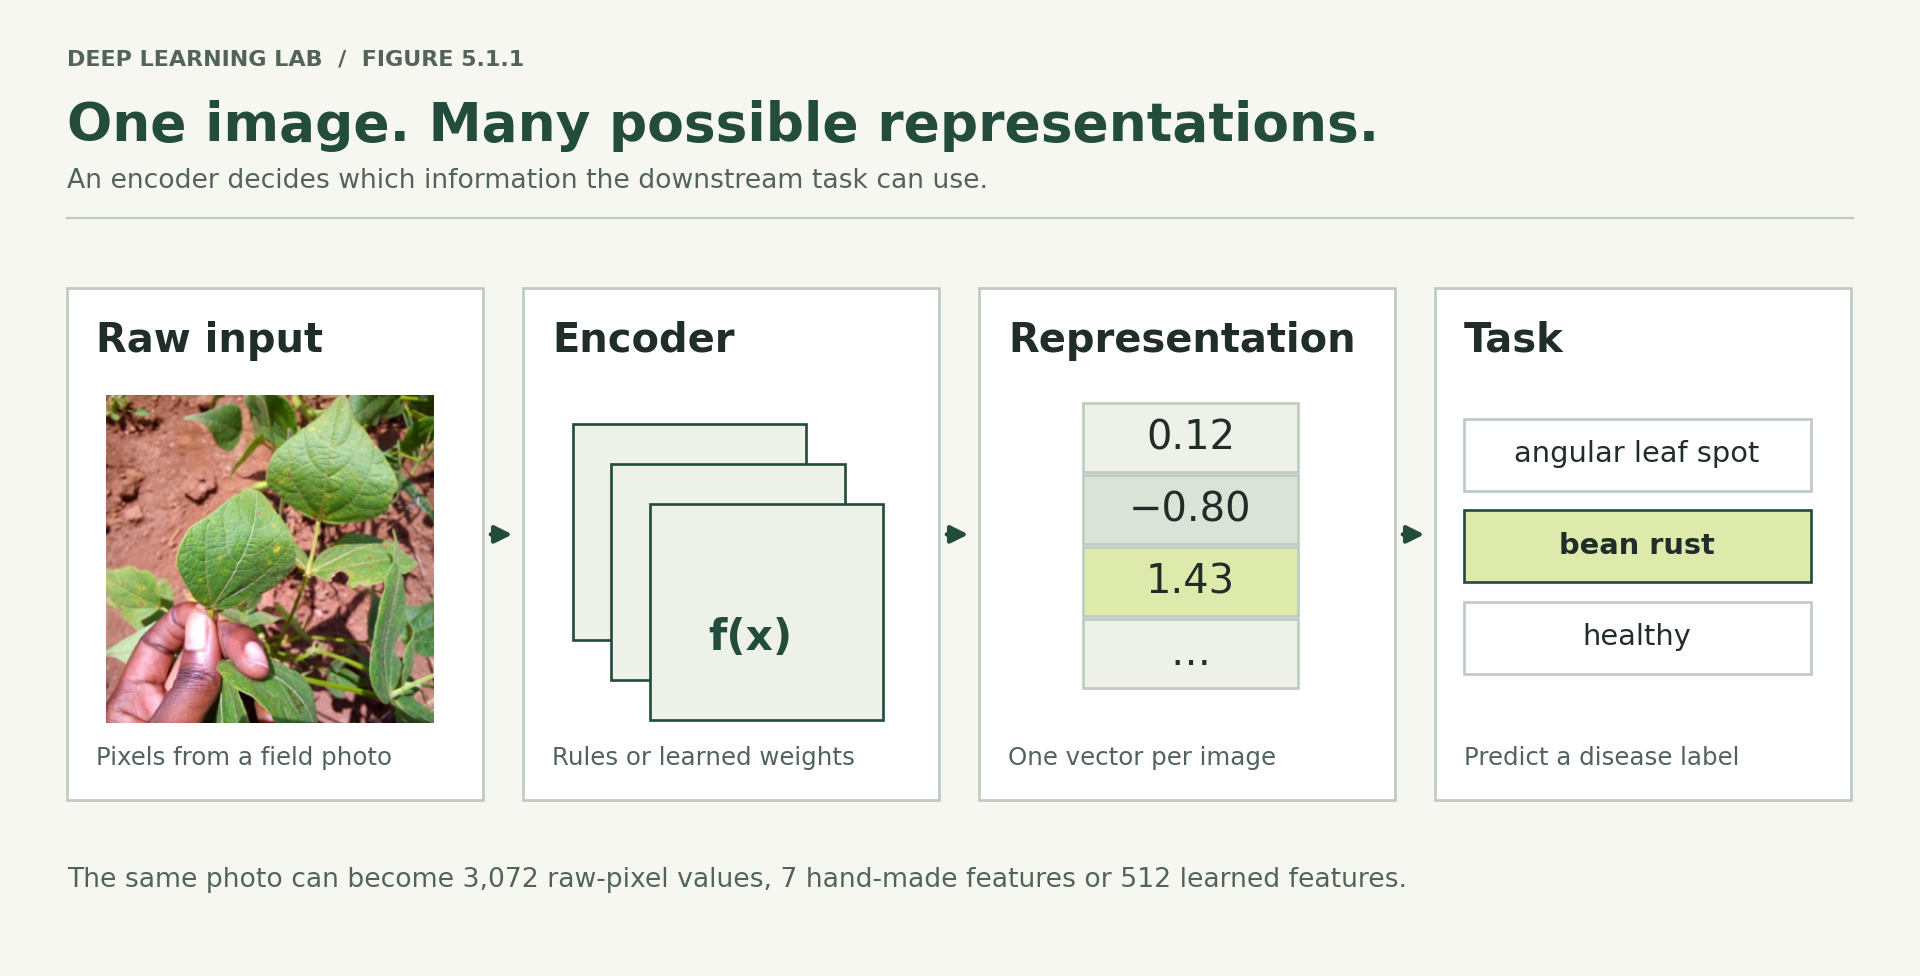

<p><b>Figure 5.1.1.</b> Raw input → encoder → representation → task. A real Beans photo illustrates the input; the vector and prediction are schematic.</p>

</div>

### How we will judge a representation

We need a fair way to say "this representation is better than that one". We will use **k-nearest neighbours**, usually shortened to **kNN**.

Here is how kNN works:

1. Keep a set of photos whose labels we know. We call this the **reference set**.
2. For a new photo, turn it into numbers with the encoder.
3. Find the *k* photos in the reference set whose numbers are closest to it. "Closest" here means the smallest straight-line distance between the two lists of numbers (called **Euclidean distance**).
4. Predict the label that most of those *k* neighbours have.

Why kNN is a good judge here: kNN learns nothing of its own. It only uses distances in the representation. So if kNN does well, it is because the representation already puts photos of the same disease close together. Its accuracy is a direct score for the representation.

We will use *k* = 5 everywhere in this note, so that the only thing that changes between experiments is the representation.

## 4. Meet the images

### Downloading the data

The Beans photos are stored as zip files on the Hugging Face website. You do not need an account to download them.

`urllib.request.urlretrieve(url, path)` downloads the file at `url` and saves it at `path`. We only download if the file is not already there, so running the cell twice does not download twice.

In [5]:
BEANS_URL = "https://huggingface.co/datasets/AI-Lab-Makerere/beans/resolve/main/data/{split}.zip"

for split in ["validation", "test"]:
    zip_path = DATA_DIR / f"beans_{split}.zip"
    if not zip_path.exists():
        urllib.request.urlretrieve(BEANS_URL.format(split=split), zip_path)
    size_mb = zip_path.stat().st_size / 1e6
    print(f"{zip_path.name:24} {size_mb:5.1f} MB")

beans_validation.zip      18.5 MB


beans_test.zip            17.7 MB


A zip file holds many files packed together. `zipfile.ZipFile(path).extractall(folder)` unpacks all of them into `folder`.

In [6]:
BEANS_DIR = DATA_DIR / "beans"
for split in ["validation", "test"]:
    if not (BEANS_DIR / split).exists():
        zipfile.ZipFile(DATA_DIR / f"beans_{split}.zip").extractall(BEANS_DIR)

print(sorted(p.name for p in BEANS_DIR.iterdir()))
print(sorted(p.name for p in (BEANS_DIR / "validation").iterdir()))

['test', 'validation']
['angular_leaf_spot', 'bean_rust', 'healthy']


Each split has one folder per class, and the folder name *is* the label. Let us count the photos in each folder.

`Path.glob("*.jpg")` lists every file in a folder whose name ends in `.jpg`.

In [7]:
CLASSES = sorted(p.name for p in (BEANS_DIR / "validation").iterdir())
print("Classes:", CLASSES)

for split in ["validation", "test"]:
    counts = {c: len(list((BEANS_DIR / split / c).glob("*.jpg"))) for c in CLASSES}
    print(split, counts, "total", sum(counts.values()))

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
validation {'angular_leaf_spot': 44, 'bean_rust': 45, 'healthy': 44} total 133
test {'angular_leaf_spot': 43, 'bean_rust': 43, 'healthy': 42} total 128


We will use the **validation** split as our reference set (the photos kNN looks up) and the **test** split as the photos we predict. The three classes are almost exactly balanced, so guessing at random would be right about one time in three. Keep **0.33** in mind as the "no skill" level.

### One photo, opened

`Image.open(path)` from the Pillow library (imported as `PIL`) opens an image file. `.size` gives `(width, height)` in pixels and `.mode` tells us how colours are stored. `"RGB"` means every pixel has three numbers: red, green and blue.

In [8]:
first_file = sorted((BEANS_DIR / "validation" / "bean_rust").glob("*.jpg"))[0]
photo = Image.open(first_file)

print("File: ", first_file.name)
print("Size: ", photo.size)
print("Mode: ", photo.mode)

File:  bean_rust_val.0.jpg
Size:  (500, 500)
Mode:  RGB


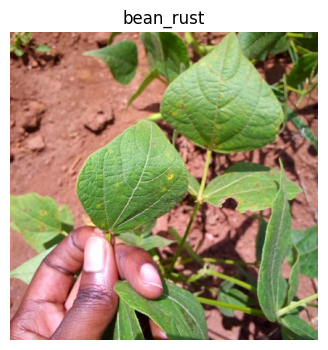

In [9]:
plt.figure(figsize=(4, 4))
plt.imshow(photo)
plt.title("bean_rust")
plt.axis("off")
plt.show()

Let us look at three photos from each class side by side, so we know what the model is up against.

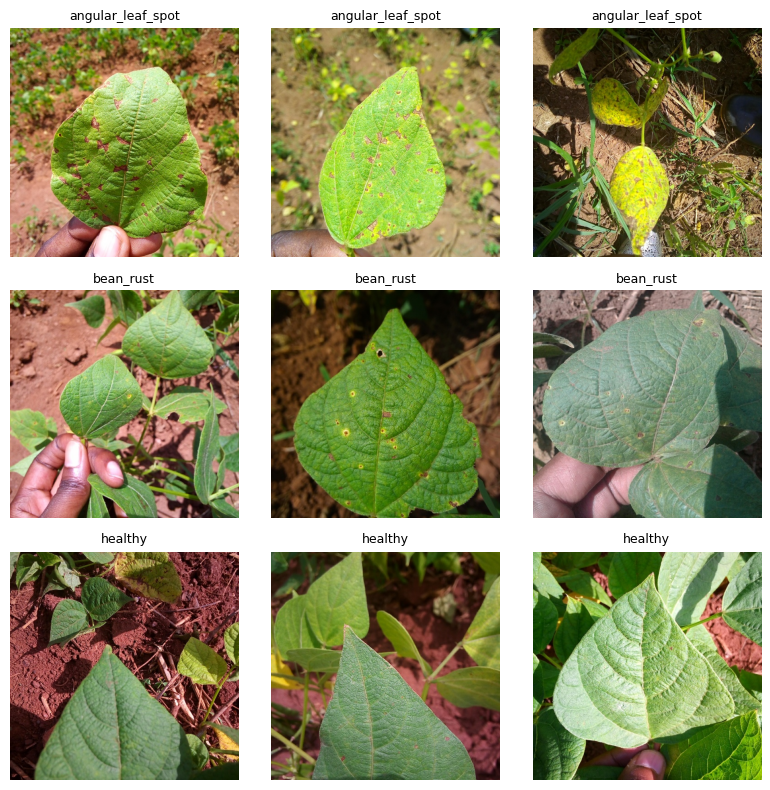

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for row, label in enumerate(CLASSES):
    files = sorted((BEANS_DIR / "validation" / label).glob("*.jpg"))[:3]
    for col, f in enumerate(files):
        axes[row, col].imshow(Image.open(f))
        axes[row, col].set_title(label, fontsize=9)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

Notice how much changes from photo to photo that has nothing to do with disease: the background (soil, other leaves, a hand), the light, the angle, how big the leaf is in the frame. A good representation must ignore all of that and keep the spots and the rust.

> **Questions to sit with**
>
> 1. Without reading the titles, could you tell *angular leaf spot* from *bean rust*? What are you looking at when you decide?
> 2. Which things in these photos would you want a representation to *ignore*?

### From a photo to a tensor

Models do not take photos. They take tensors (Day 2, note 2.1). We use three small tools from `torchvision.transforms`:

- `transforms.Resize((224, 224))` makes every photo 224 pixels wide and 224 pixels tall. The Beans photos are 500 × 500, and the pretrained network in Section 9 expects 224 × 224.
- `transforms.ToTensor()` turns the photo into a tensor of shape `(3, 224, 224)`: three colour channels, then height, then width. It also divides every value by 255, so each number lies between 0 and 1.
- `transforms.Compose([...])` chains tools so they run one after another.

In [11]:
to_tensor = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

x = to_tensor(photo)
print("Shape:", tuple(x.shape))
print("Type: ", x.dtype)
print("Smallest value:", round(x.min().item(), 4), " largest value:", round(x.max().item(), 4))

Shape: (3, 224, 224)
Type:  torch.float32
Smallest value: 0.0  largest value: 1.0


Let us index into it. `x[:, 0, 0]` means "all three channels, row 0, column 0": the red, green and blue values of the top-left pixel. `x[1]` is the whole green channel, a 224 × 224 grid.

In [12]:
print("Top-left pixel (red, green, blue):", x[:, 0, 0])
print("Green channel shape:", tuple(x[1].shape))
print("Numbers in one photo:", x.numel())

Top-left pixel (red, green, blue): tensor([0.6196, 0.3725, 0.3020])
Green channel shape: (224, 224)
Numbers in one photo: 150528


One small photo is already **150,528** numbers (3 × 224 × 224). Remember that number.

### Loading every photo

Now we do the same thing to every photo. The function below walks through each class folder, turns each photo into a tensor, and records the label as a whole number: 0, 1 or 2, in the order of `CLASSES`.

`torch.stack(list_of_tensors)` puts many tensors of the same shape on top of each other, making one bigger tensor with a new first dimension.

In [13]:
def load_split(split):
    tensors, labels = [], []
    for label_number, label in enumerate(CLASSES):
        for f in sorted((BEANS_DIR / split / label).glob("*.jpg")):
            tensors.append(to_tensor(Image.open(f).convert("RGB")))
            labels.append(label_number)
    return torch.stack(tensors), np.array(labels)

X_ref, y_ref = load_split("validation")
X_test, y_test = load_split("test")
print("Reference photos:", tuple(X_ref.shape), " labels:", y_ref.shape)
print("Test photos:     ", tuple(X_test.shape), " labels:", y_test.shape)

Reference photos: (133, 3, 224, 224)  labels: (133,)
Test photos:      (128, 3, 224, 224)  labels: (128,)


How much memory do these tensors take? On Day 4 (note 4.3) we learned the rule: *number of values × bytes per value*. Each value is a `float32`, which takes 4 bytes. `.element_size()` tells us the bytes per value.

In [14]:
for name, t in [("X_ref", X_ref), ("X_test", X_test)]:
    mb = t.numel() * t.element_size() / 1e6
    print(f"{name:7} {t.numel():>11,} values x {t.element_size()} bytes = {mb:6.1f} MB")

X_ref    20,020,224 values x 4 bytes =   80.1 MB
X_test   19,267,584 values x 4 bytes =   77.1 MB


## 5. Raw pixels as a representation

The simplest representation of a photo is the pixels themselves, written out in one long row. We call this **flattening**.

150,528 numbers per photo makes kNN slow, so we first shrink each photo to 32 × 32. `F.interpolate(X, size=(32, 32), mode="area")` does this by averaging each block of pixels into one. Then `.flatten(start_dim=1)` keeps the first dimension (one row per photo) and lays everything else out in a line.

In [15]:
def raw_pixels(X):
    small = F.interpolate(X, size=(32, 32), mode="area")
    return small.flatten(start_dim=1).numpy()

R_ref = raw_pixels(X_ref)
R_test = raw_pixels(X_test)
print("Raw-pixel representation:", R_ref.shape, "and", R_test.shape)

Raw-pixel representation: (133, 3072) and (128, 3072)


Each photo is now **3,072** numbers (3 × 32 × 32). This is our first representation.

Now we score it with kNN. In scikit-learn:

- `KNeighborsClassifier(n_neighbors=5)` makes a kNN that looks at the 5 closest reference photos.
- `.fit(R_ref, y_ref)` does not train anything. It just stores the reference photos and their labels.
- `.score(R_test, y_test)` predicts a label for each test photo and returns the fraction it got right, called **accuracy**.

We wrap this in a small function, because we will score four representations the same way.

In [16]:
def knn_accuracy(ref_features, test_features, k=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(ref_features, y_ref)
    return knn.score(test_features, y_test)

acc_raw = knn_accuracy(R_ref, R_test)
print(f"kNN accuracy on raw pixels: {acc_raw:.4f}")
print(f"Random guessing:            {1/3:.4f}")

kNN accuracy on raw pixels: 0.5938
Random guessing:            0.3333


Raw pixels beat random guessing, but not by a lot. To see *why*, let us look at what kNN actually finds. The function below takes one test photo, finds its 5 nearest reference photos, and shows them with their labels.

`knn.kneighbors(features, n_neighbors=5)` returns two arrays: the distances to the 5 nearest reference photos, and their positions in the reference set.

In [17]:
def show_neighbours(ref_features, test_features, test_index, title):
    knn = KNeighborsClassifier(n_neighbors=5).fit(ref_features, y_ref)
    distances, positions = knn.kneighbors(test_features[test_index:test_index + 1])
    fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
    axes[0].imshow(X_test[test_index].permute(1, 2, 0))
    axes[0].set_title("TEST\n" + CLASSES[y_test[test_index]], fontsize=9)
    for j, (d, p) in enumerate(zip(distances[0], positions[0]), start=1):
        axes[j].imshow(X_ref[p].permute(1, 2, 0))
        axes[j].set_title(f"{CLASSES[y_ref[p]]}\ndistance {d:.1f}", fontsize=9)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title)
    plt.show()
    return positions[0]

QUERY = 61   # one test photo we will keep coming back to
print("Test photo", QUERY, "is", CLASSES[y_test[QUERY]])

Test photo 61 is bean_rust


We chose test photo 61 on purpose: it is a photo where raw pixels and the pretrained network of Section 9 disagree, so the difference is easy to see. One photo proves nothing on its own. The scores and the photo-by-photo count in Section 9 are the real evidence.

`.permute(1, 2, 0)` reorders the tensor from `(channels, height, width)` to `(height, width, channels)`, because that is the order matplotlib expects for drawing.

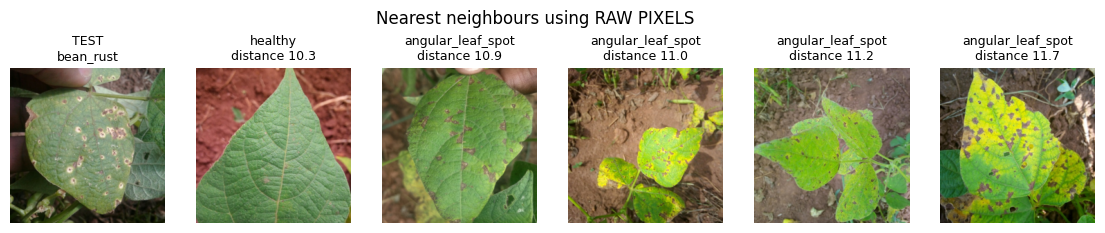

Neighbour labels: ['healthy', 'angular_leaf_spot', 'angular_leaf_spot', 'angular_leaf_spot', 'angular_leaf_spot']


In [18]:
raw_neighbours = show_neighbours(R_ref, R_test, QUERY, "Nearest neighbours using RAW PIXELS")
print("Neighbour labels:", [CLASSES[y_ref[p]] for p in raw_neighbours])

Look at the neighbours. Do they share the *disease*, or do they share the *lighting and the background*? Raw-pixel distance asks "are the same dots the same colour in the same place?" That question is mostly about brightness and layout, not about spots.

### The shift test

Here is a sharper way to see the problem. Take one photo and slide it to the side by 20 pixels. To a person it is the same leaf. What does raw-pixel distance think?

`torch.roll(x, shifts=20, dims=3)` slides the tensor 20 steps along dimension 3. Whatever falls off the right edge comes back on the left.

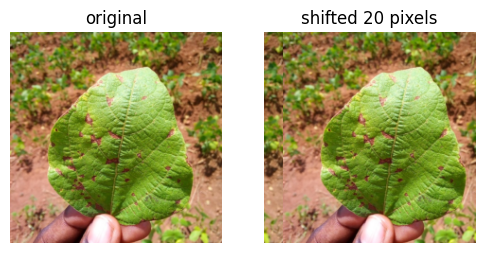

In [19]:
original = X_ref[0:1]
shifted = torch.roll(original, shifts=20, dims=3)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original[0].permute(1, 2, 0)); axes[0].set_title("original")
axes[1].imshow(shifted[0].permute(1, 2, 0)); axes[1].set_title("shifted 20 pixels")
for ax in axes: ax.axis("off")
plt.show()

Why dimension 3? The tensor `X_ref[0:1]` keeps the first dimension, so its shape is `(1, 3, 224, 224)`: photo, channel, height, width. Width is dimension 3. Getting the dimension number right is the shape-debugging habit from Day 2.

Now we measure. We compare two distances:

- the distance from the photo to **its own shifted copy**, and
- the distance from the photo to **every other reference photo**, of which we take the middle value (the **median**).

If the representation understands that a shifted leaf is the same leaf, the first distance should be far smaller than the second. `np.linalg.norm(a - b)` gives the Euclidean distance between `a` and `b`.

In [20]:
def shift_test(encode):
    a = encode(original)[0]
    b = encode(shifted)[0]
    others = encode(X_ref[1:])
    to_shifted = np.linalg.norm(a - b)
    to_others = np.median(np.linalg.norm(others - a, axis=1))
    return to_shifted, to_others

to_shifted, to_others = shift_test(raw_pixels)
print(f"Raw pixels: distance to its own shifted copy  = {to_shifted:.2f}")
print(f"Raw pixels: median distance to other photos   = {to_others:.2f}")
print(f"Ratio (shifted / others) = {to_shifted / to_others:.2f}")

Raw pixels: distance to its own shifted copy  = 9.66
Raw pixels: median distance to other photos   = 13.88
Ratio (shifted / others) = 0.70


The shifted copy sits at a distance of **9.66**. A typical *other* photo, of a different leaf, often of a different class, sits at **13.88**. The ratio is **0.70**.

So to raw pixels, the same leaf moved sideways looks only a little more alike than a completely different photo. A person would put the shifted copy at almost zero distance, because nothing about the leaf changed. Raw pixels see the change in *where* and miss that *what* stayed the same.

> **Questions to sit with**
>
> 1. A farmer's phone will never hold the leaf in exactly the same spot twice. What does that mean for a model built on raw pixels?
> 2. Shrinking photos to 32 × 32 threw away detail. Could the spots on an angular-leaf-spot leaf even survive that shrinking?

## 6. Hand-made features: the first idea people had

Before neural networks became practical for photos, people wrote the encoder by hand. They thought hard about what matters and wrote rules to measure it. These are called **hand-made** (or **handcrafted**) features.

Let us try it. Healthy leaves look green. Diseased leaves have brown or rusty patches. So here are seven numbers per photo:

- the average red, green and blue value (3 numbers): how much of each colour the photo has overall;
- the spread of red, green and blue values, measured by the **standard deviation** (3 numbers): is the colour even, or patchy?
- the fraction of pixels where red is larger than green (1 number): a rough "how much brown or orange is there" measure.

In the code, `X.mean(dim=(2, 3))` averages over height and width (dimensions 2 and 3), leaving one number per channel per photo. `torch.cat([...], dim=1)` joins the pieces side by side.

In [21]:
def handmade_features(X):
    mean_colour = X.mean(dim=(2, 3))                       # shape (photos, 3)
    spread = X.std(dim=(2, 3))                             # shape (photos, 3)
    red, green = X[:, 0], X[:, 1]
    brownish = (red > green).float().mean(dim=(1, 2))      # shape (photos,)
    return torch.cat([mean_colour, spread, brownish[:, None]], dim=1).numpy()

H_ref = handmade_features(X_ref)
H_test = handmade_features(X_test)
print("Hand-made representation:", H_ref.shape)
print("First reference photo:", np.round(H_ref[0], 3))

Hand-made representation: (133, 7)
First reference photo: [0.564 0.527 0.267 0.189 0.179 0.191 0.519]


These seven numbers are on different scales, and kNN uses distance, so a feature with big numbers would drown out the rest. `StandardScaler` (which you know from machine learning) shifts and stretches each feature so it has an average of 0 and a standard deviation of 1. We **fit it on the reference set only**, then apply it to both sets. That is the Day 4 rule: never let the test data shape the preprocessing.

In [22]:
scaler = StandardScaler().fit(H_ref)
acc_handmade = knn_accuracy(scaler.transform(H_ref), scaler.transform(H_test))

print(f"kNN accuracy, raw pixels (3,072 numbers): {acc_raw:.4f}")
print(f"kNN accuracy, hand-made (7 numbers):      {acc_handmade:.4f}")

kNN accuracy, raw pixels (3,072 numbers): 0.5938
kNN accuracy, hand-made (7 numbers):      0.6328


Seven hand-made numbers (**0.6328**) beat 3,072 raw pixels (**0.5938**). A person's idea of what matters, colour and patchiness, is worth more than thousands of numbers that do not know what matters.

Be careful with the size of that win, though. With 128 test photos, 0.5938 is 76 photos right and 0.6328 is 81. The gap is 5 photos. It is a real hint, not proof.

The bigger problem with hand-made features is not their accuracy. It is that **every new problem needs a new person with a new idea**. My "red larger than green" rule means nothing for X-rays, for satellite photos, or for telling cats from dogs. It does not scale.

The question that changed the field was: *can the encoder learn its own features from the data?*

## 7. What a convolution does

The kind of network that first answered "yes" for photos is the **convolutional neural network**, or **CNN**. You only need to know what it is and why it mattered; you will not build one today.

### A filter is a tiny grid of weights

A **filter** (also called a **kernel**) is a small grid of numbers, for example 3 × 3. A **convolution** slides that grid across the photo. At every position it multiplies the 9 numbers of the filter by the 9 pixels under it and adds them up, giving one output number. Doing this at every position gives a new grid, called a **feature map**.

<div align="center">

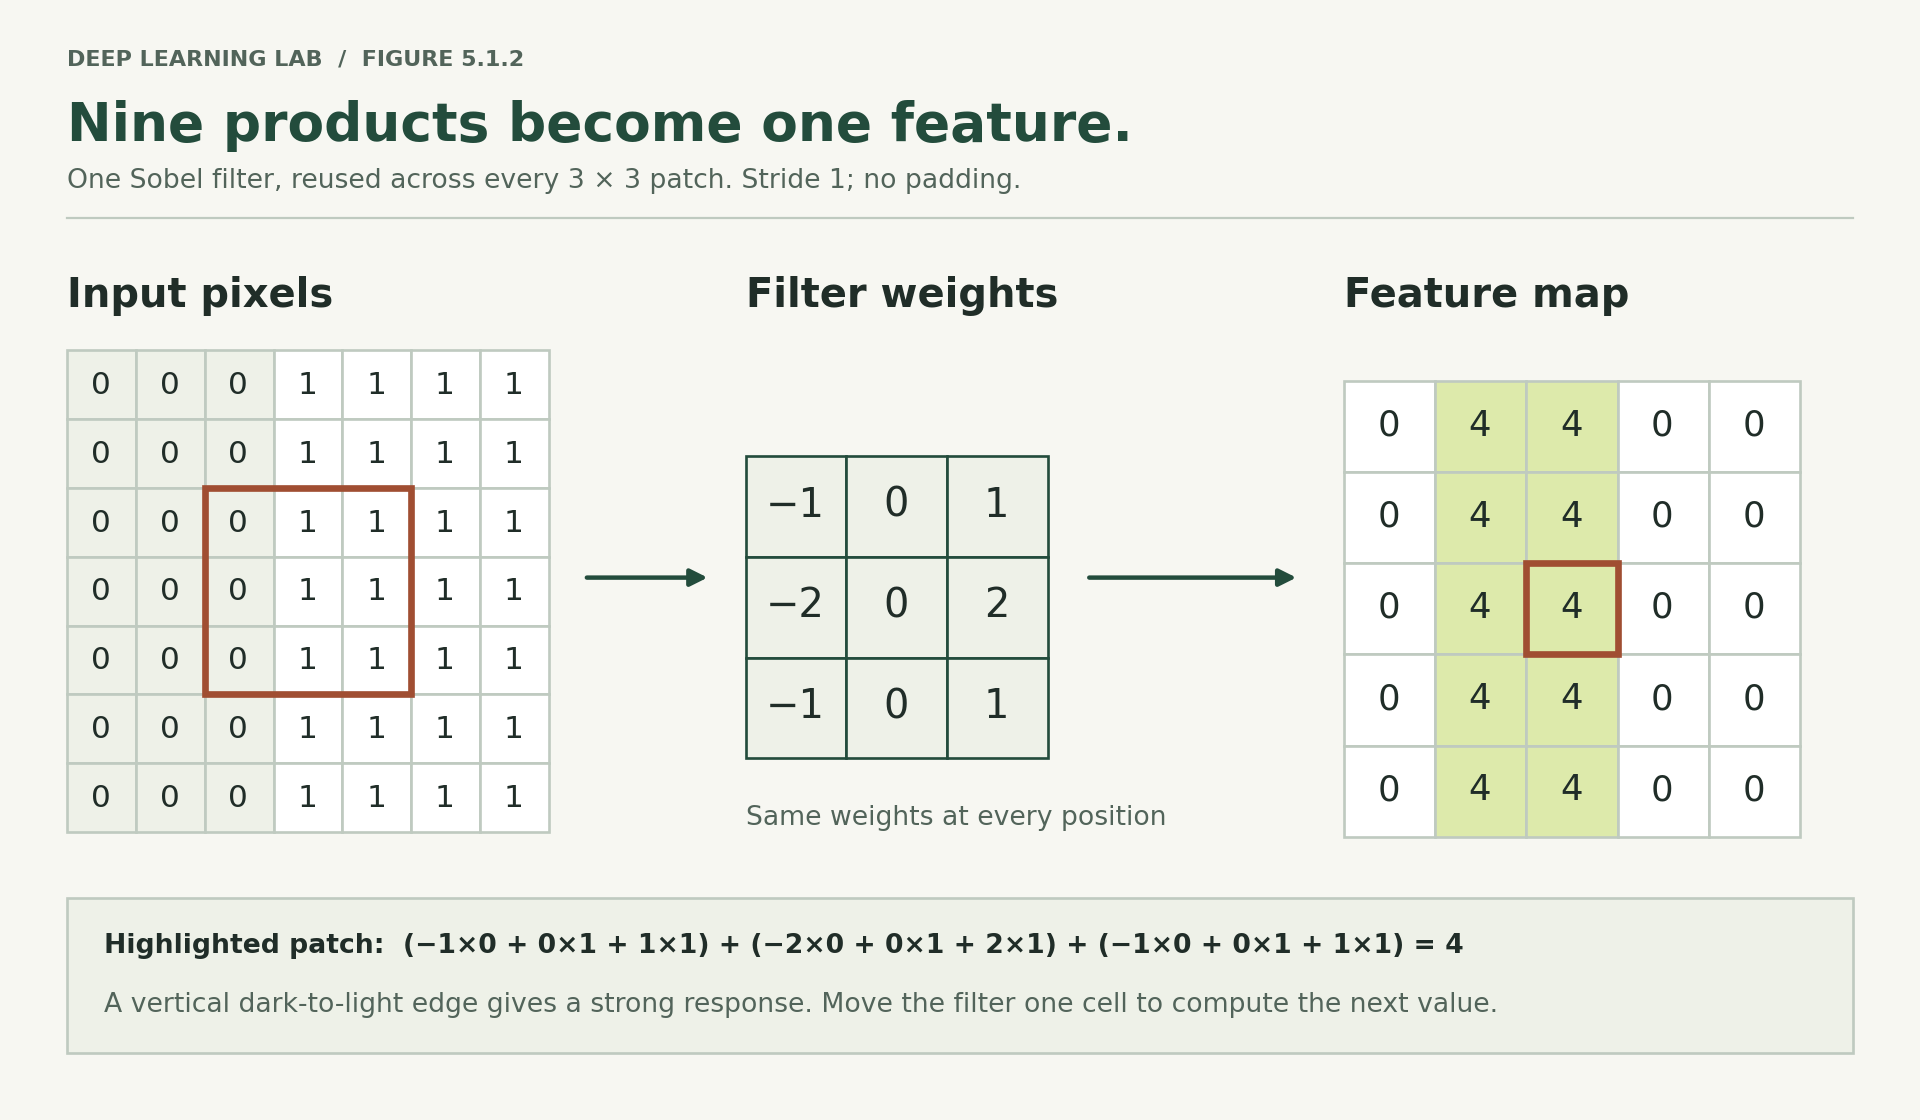

<p><b>Figure 5.1.2.</b> A 7 × 7 input and a 3 × 3 Sobel kernel produce a 5 × 5 feature map. The outlined output is exactly 4.</p>

</div>

Let us build one by hand. This filter is negative on the left and positive on the right, so it gives a big answer wherever the photo changes from dark to bright going left to right: a **vertical edge**.

In [23]:
vertical_edge = torch.tensor([[-1., 0., 1.],
                              [-2., 0., 2.],
                              [-1., 0., 1.]])
print("Filter shape:", tuple(vertical_edge.shape))
print(vertical_edge)

Filter shape: (3, 3)
tensor([[-1.,  0.,  1.],
        [-2.,  0.,  2.],
        [-1.,  0.,  1.]])


We apply it with `F.conv2d(input, weight, padding=1)`.

- `input` must have shape `(photos, channels, height, width)`. We use one photo in grey, so `(1, 1, 224, 224)`. We make the photo grey by averaging its three colour channels.
- `weight` must have shape `(output channels, input channels, filter height, filter width)`, so `(1, 1, 3, 3)`.
- `padding=1` adds a border of zeros one pixel wide, so the output keeps the size 224 × 224.

`t[None, None]` adds two dimensions of size 1 at the front, turning a `(224, 224)` grid into `(1, 1, 224, 224)`.

In [24]:
grey = X_ref[0].mean(dim=0)                     # (224, 224)
edges = F.conv2d(grey[None, None], vertical_edge[None, None], padding=1)
print("Input shape: ", tuple(grey[None, None].shape))
print("Output shape:", tuple(edges.shape))

Input shape:  (1, 1, 224, 224)
Output shape: (1, 1, 224, 224)


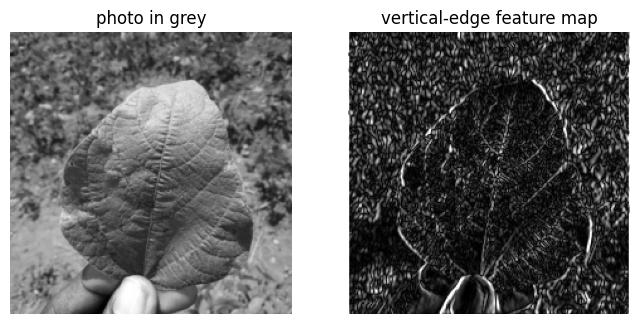

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(grey, cmap="gray"); axes[0].set_title("photo in grey")
edge_strength = edges[0, 0].abs()
axes[1].imshow(edge_strength, cmap="gray", vmax=edge_strength.quantile(0.99).item())
axes[1].set_title("vertical-edge feature map")
for ax in axes: ax.axis("off")
plt.show()

The bright lines on the right are where the filter "fired": the outline of the leaf, the veins, the fingers holding it. (`vmax=...quantile(0.99)` just sets the brightest grey to the 99th-percentile value so the picture is not too dark to see.)

Notice that it also fires all over the soil in the background. A single filter has no idea what matters. It finds *every* vertical edge, useful or not. Deciding which edges matter is the job of the layers that come after it.

Two properties make this powerful:

- **Locality.** Each output number only looks at a small 3 × 3 patch. Edges, spots and textures are local things, so this is the right way to look.
- **Weight sharing.** The *same* 9 weights are used at every position. A spot is a spot whether it is at the top of the photo or the bottom, so one filter can find it anywhere.

In a real CNN, nobody writes the filters by hand. The filter numbers are **weights**, learned by the same gradient descent you used on Day 1. The network learns which edges and textures are useful.

### Why weight sharing matters: count the weights

Let us compare two layers that both take a 3 × 224 × 224 photo and make 64 outputs.

- `nn.Conv2d(3, 64, kernel_size=3)` learns 64 filters, each 3 × 3, each looking at 3 colour channels.
- `nn.Linear(150528, 64)` is the fully connected layer from Day 2, which connects every one of the 150,528 input numbers to every one of the 64 outputs.

`p.numel()` counts the numbers in one weight tensor, and we add them up over `layer.parameters()`.

In [26]:
conv = nn.Conv2d(3, 64, kernel_size=3)
dense = nn.Linear(3 * 224 * 224, 64)

conv_weights = sum(p.numel() for p in conv.parameters())
dense_weights = sum(p.numel() for p in dense.parameters())
print(f"Conv2d(3, 64, 3) weights:     {conv_weights:>11,}")
print(f"Linear(150528, 64) weights:   {dense_weights:>11,}")
print(f"The Linear layer has {dense_weights / conv_weights:,.0f} times more weights")

Conv2d(3, 64, 3) weights:           1,792
Linear(150528, 64) weights:     9,633,856
The Linear layer has 5,376 times more weights


The convolution layer has **1,792** weights. The fully connected layer has **9,633,856**, more than five thousand times as many, for the same input. A fully connected network on photos would be huge, slow, and would overfit (Day 3, note 3.2) badly. Weight sharing is the reason CNNs made learning from photos practical.

### Stacking layers

A real CNN stacks many convolution layers. The first layers learn simple things like edges. Later layers combine edges into textures, then textures into parts (a spot, a vein pattern, a leaf edge). Along the way, **pooling** steps shrink the feature maps, so the final numbers care more about *what* is in the photo and less about exactly *where*.

At the end, the network averages each final feature map into one number. The result is one list of numbers for the whole photo: a learned representation.

<div align="center">

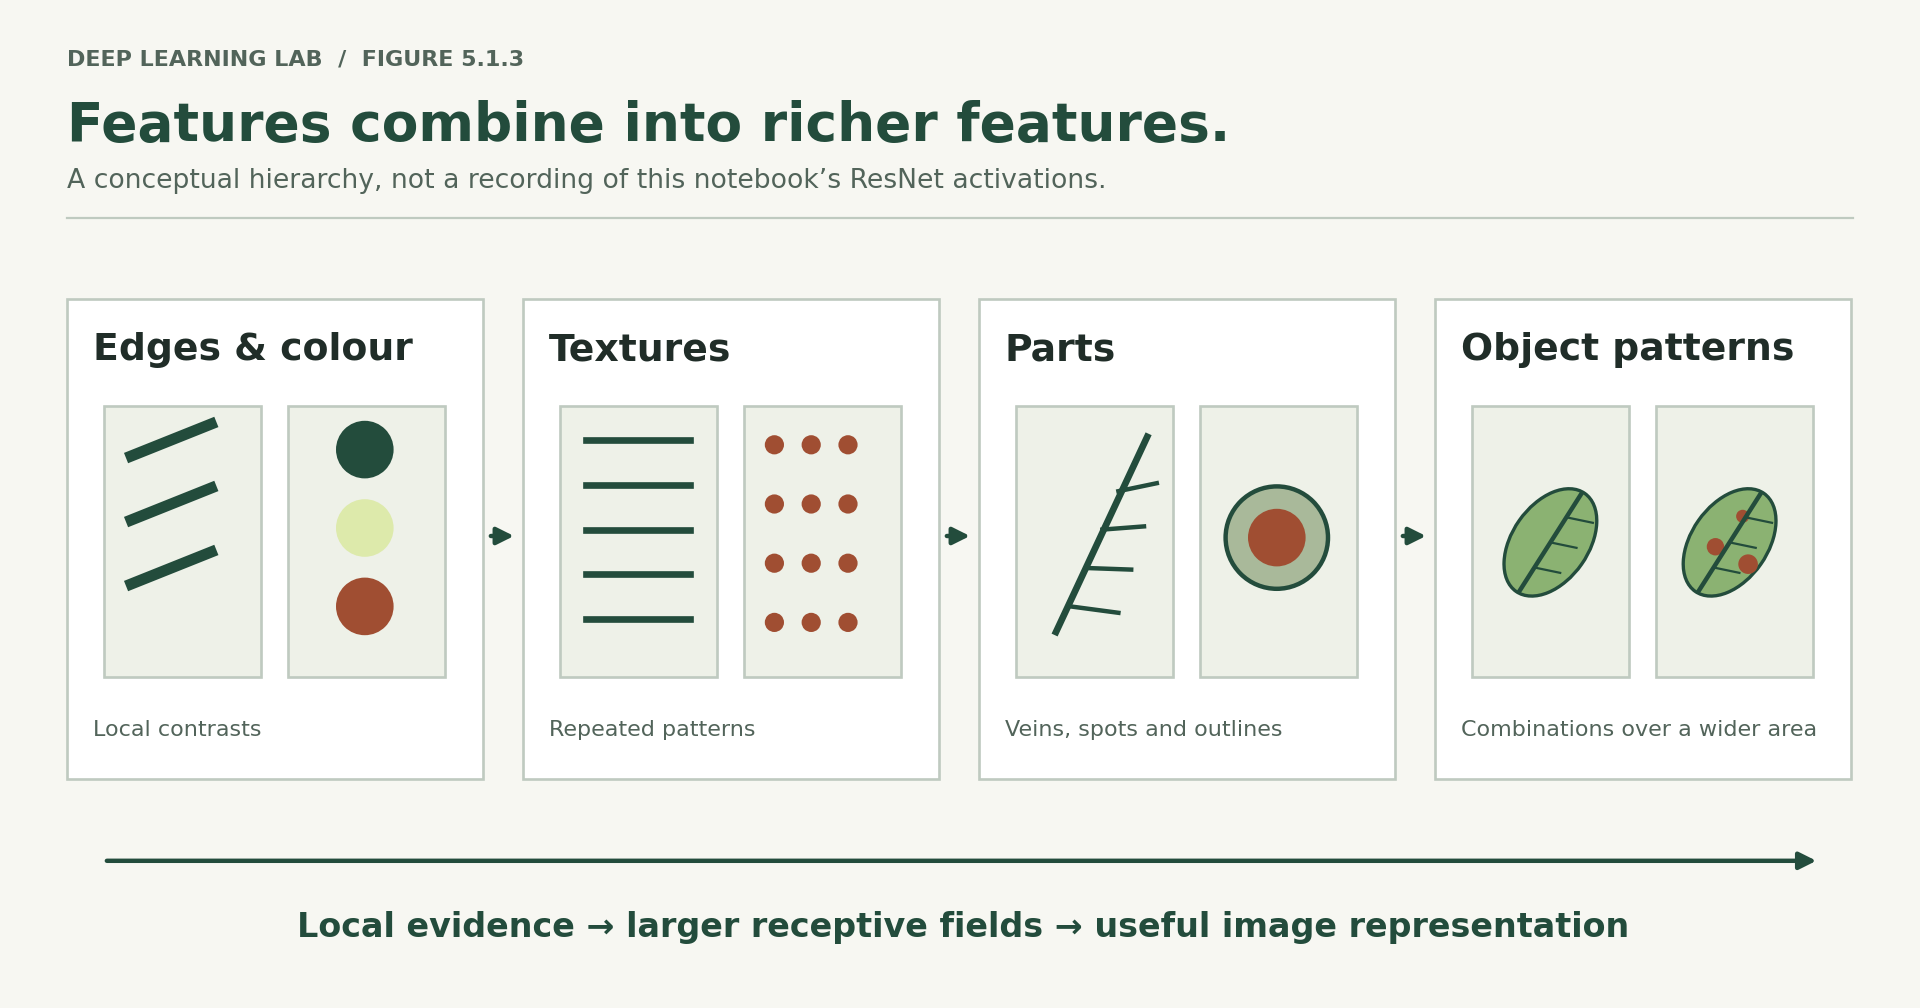

<p><b>Figure 5.1.3.</b> Early layers detect local patterns; deeper layers combine evidence over wider receptive fields. These are illustrative motifs, not literal feature maps.</p>

</div>

## 8. A CNN with random weights

We will use a real, widely used CNN called **ResNet-18**. "ResNet" stands for *residual network*: it uses the residual connections you met on Day 3 (note 3.3), which let gradients flow through many layers. "18" is the number of layers that have weights.

`torchvision.models.resnet18(weights=None)` builds the network with **random** weights, the way any network starts before training. We fix the random seed first (Day 4, note 4.2) so you get the same random weights as this note.

In [27]:
torch.manual_seed(0)
random_cnn = torchvision.models.resnet18(weights=None)
n_weights = sum(p.numel() for p in random_cnn.parameters())
print(f"ResNet-18 has {n_weights:,} weights")

ResNet-18 has 11,689,512 weights

Let us look at its last layer. `random_cnn.fc` is the final fully connected layer ("fc"). It turns 512 numbers into 1,000 class scores, because ResNet-18 was designed for a 1,000-class photo task.

In [28]:
print(random_cnn.fc)

Linear(in_features=512, out_features=1000, bias=True)


We do not want 1,000 class scores. We want the **512 numbers that come just before** that last layer: the representation. So we replace the last layer with `nn.Identity()`, a layer that does nothing at all: it returns exactly what it receives. Now the network's output *is* the 512-number representation.

In [29]:
random_cnn.fc = nn.Identity()
random_cnn.eval()
print(random_cnn.fc)

Identity()


`.eval()` switches the network into *evaluation mode*. ResNet-18 contains BatchNorm layers (Day 3, note 3.3), which behave differently during training. In evaluation mode they use their stored statistics instead of the current batch, so each photo's numbers do not depend on which other photos are in the batch.

### Getting features out

Two more steps before photos go in:

- **Normalising.** ResNet-18 expects each colour channel to be shifted and scaled by fixed numbers (the average and spread of colours in its training photos). `transforms.Normalize(mean, std)` does that.
- **`torch.no_grad()`.** We are not training, so we tell PyTorch not to record the steps for backpropagation (Day 1). This saves memory and time.

We push photos through in batches of 32, then join the results.

In [30]:
normalise = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def cnn_features(network, X, batch_size=32):
    outputs = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = normalise(X[start:start + batch_size])
            outputs.append(network(batch))
    return torch.cat(outputs).numpy()

In [31]:
start = time.perf_counter()
C_ref = cnn_features(random_cnn, X_ref)
C_test = cnn_features(random_cnn, X_test)
print("Random-CNN representation:", C_ref.shape, "and", C_test.shape)
print(f"Took {time.perf_counter() - start:.1f} seconds on this machine")

Random-CNN representation: (133, 512) and (128, 512)
Took 17.2 seconds on this machine


In [32]:
acc_random_cnn = knn_accuracy(C_ref, C_test)
print(f"kNN accuracy, raw pixels:   {acc_raw:.4f}")
print(f"kNN accuracy, hand-made:    {acc_handmade:.4f}")
print(f"kNN accuracy, random CNN:   {acc_random_cnn:.4f}")

kNN accuracy, raw pixels:   0.5938
kNN accuracy, hand-made:    0.6328
kNN accuracy, random CNN:   0.5781


This is worth reading slowly. The random CNN scored **0.5781**: 74 of 128 photos right. That is 2 photos *fewer* than raw pixels, and 7 fewer than the seven hand-made numbers. A difference of 2 photos is well inside the noise, so the fair reading is: **a CNN with random weights is no better than raw pixels here.**

When this note was planned, the expectation was that the CNN's design alone would help a little. On these photos, measured this way, it did not. That is a useful lesson in itself. The design of a CNN, with its locality and weight sharing, makes it *possible* to learn good filters. It does not learn them for you. Random filters respond to random patterns, and 11.7 million random weights are not a representation of bean disease.

> **Questions to sit with**
>
> 1. The random CNN has 11,689,512 weights and did no better than raw pixels. What does that tell you about where the value of a neural network comes from: the design, or the learned weights?
> 2. In Section 9 we keep exactly the same design and change only the weights. What do you predict?

## 9. The same CNN after training on ImageNet

### What ImageNet is

**ImageNet** is a large collection of about 1.28 million photos, each labelled with one of 1,000 classes: dog breeds, birds, vehicles, tools, foods, and so on. For years, training on it was the standard test for photo models. A network trained on ImageNet has learned edges, textures and parts that are useful for photos in general.

`ResNet18_Weights.IMAGENET1K_V1` names a set of weights that someone trained on ImageNet and published. Passing it to `resnet18(weights=...)` downloads those weights (46.8 MB) the first time, and reuses the saved copy after that.

In [33]:
imagenet_weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
pretrained_cnn = torchvision.models.resnet18(weights=imagenet_weights)
pretrained_cnn.fc = nn.Identity()
pretrained_cnn.eval()
print("Loaded weights:", imagenet_weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  9%|▊         | 3.88M/44.7M [00:00<00:01, 39.4MB/s]

 49%|████▉     | 22.0M/44.7M [00:00<00:00, 127MB/s] 

 89%|████████▉ | 39.8M/44.7M [00:00<00:00, 153MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]

Loaded weights: ResNet18_Weights.IMAGENET1K_V1


A network whose weights were trained on one task and then reused is called **pretrained**.

Before we use it, a fair question: did ImageNet already teach this network about bean diseases? If it did, our test is not fair. The weights come with the list of the 1,000 class names, in `imagenet_weights.meta["categories"]`. Let us search it.

In [34]:
categories = imagenet_weights.meta["categories"]
print("Number of ImageNet classes:", len(categories))
print("First ten:", categories[:10])
for word in ["bean", "leaf", "rust", "plant"]:
    print(f"classes containing '{word}':", [c for c in categories if word in c.lower()])

Number of ImageNet classes: 1000
First ten: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']
classes containing 'bean': []
classes containing 'leaf': ['leaf beetle', 'leafhopper']
classes containing 'rust': []
classes containing 'plant': []


No class name contains "bean", "rust" or "plant". The only classes with "leaf" in the name are **leaf beetle** and **leafhopper**, which are insects. ImageNet never asked this network to tell a healthy bean leaf from a sick one. Whatever helps below must be general knowledge about photos, not a memorised answer.

Now the same three steps as before: features, then kNN.

In [35]:
start = time.perf_counter()
P_ref = cnn_features(pretrained_cnn, X_ref)
P_test = cnn_features(pretrained_cnn, X_test)
print("Pretrained-CNN representation:", P_ref.shape)
print(f"Took {time.perf_counter() - start:.1f} seconds on this machine")

Pretrained-CNN representation: (133, 512)
Took 17.5 seconds on this machine


In [36]:
acc_pretrained = knn_accuracy(P_ref, P_test)
print(f"kNN accuracy, raw pixels:      {acc_raw:.4f}")
print(f"kNN accuracy, hand-made:       {acc_handmade:.4f}")
print(f"kNN accuracy, random CNN:      {acc_random_cnn:.4f}")
print(f"kNN accuracy, pretrained CNN:  {acc_pretrained:.4f}")

kNN accuracy, raw pixels:      0.5938
kNN accuracy, hand-made:       0.6328
kNN accuracy, random CNN:      0.5781
kNN accuracy, pretrained CNN:  0.7969


The pretrained CNN scored **0.7969**: 102 of 128 photos right, against 76 for raw pixels.

Look at what changed between the random CNN and this one. Same design. Same 512 numbers per photo. Same kNN. The only difference is the weights. Learned weights took the score from 0.5781 to 0.7969. That is representation learning, measured.

Let us look at the neighbours of the same test photo again.

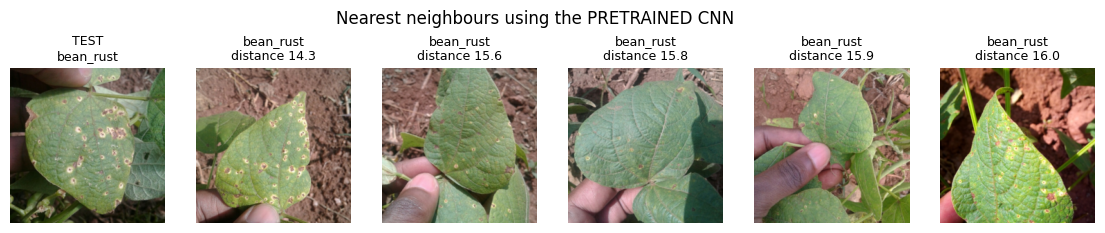

Neighbour labels: ['bean_rust', 'bean_rust', 'bean_rust', 'bean_rust', 'bean_rust']


In [37]:
pretrained_neighbours = show_neighbours(P_ref, P_test, QUERY, "Nearest neighbours using the PRETRAINED CNN")
print("Neighbour labels:", [CLASSES[y_ref[p]] for p in pretrained_neighbours])

And the shift test, now inside the pretrained network's representation. We pass a small function that normalises and runs the network, so `shift_test` can use it exactly as it used `raw_pixels`.

In [38]:
def pretrained_encode(X):
    return cnn_features(pretrained_cnn, X)

to_shifted_p, to_others_p = shift_test(pretrained_encode)
print(f"Pretrained CNN: distance to its own shifted copy = {to_shifted_p:.2f}")
print(f"Pretrained CNN: median distance to other photos  = {to_others_p:.2f}")
print(f"Ratio (shifted / others) = {to_shifted_p / to_others_p:.2f}   (raw pixels gave {to_shifted / to_others:.2f})")

Pretrained CNN: distance to its own shifted copy = 7.27
Pretrained CNN: median distance to other photos  = 19.36
Ratio (shifted / others) = 0.38   (raw pixels gave 0.70)


In the pretrained network's representation, the ratio drops from **0.70** to **0.38**. The shifted copy is now much closer to the original than a typical other photo is. The learned representation cares more about *what* is in the photo and less about *where* it is, which is exactly what we wanted from Section 7's filters and pooling.

### Is the gain bigger than the noise?

Day 4 taught us not to trust a difference until we have checked it against noise. Here every test photo is one-128th of the score, so **one photo changes accuracy by about 0.0078**.

The fair check is a **paired comparison**: both representations were scored on *the same* 128 test photos, so we can compare them photo by photo. We count photos that one representation got right and the other got wrong. Photos both got right, or both got wrong, tell us nothing about which is better.

In [39]:
pred_raw = KNeighborsClassifier(5).fit(R_ref, y_ref).predict(R_test)
pred_pre = KNeighborsClassifier(5).fit(P_ref, y_ref).predict(P_test)
right_raw = pred_raw == y_test
right_pre = pred_pre == y_test

print("Right with both:                 ", np.sum(right_raw & right_pre))
print("Right only with pretrained CNN:  ", np.sum(~right_raw & right_pre))
print("Right only with raw pixels:      ", np.sum(right_raw & ~right_pre))
print("Wrong with both:                 ", np.sum(~right_raw & ~right_pre))

Right with both:                  61
Right only with pretrained CNN:   41
Right only with raw pixels:       15
Wrong with both:                  11


61 photos were right both ways and 11 were wrong both ways; those tell us nothing about which representation is better. The informative photos are the other 56. Of those, the pretrained CNN won **41** and raw pixels won **15**.

If the two representations were equally good, each of those 56 photos would be like a coin flip, and we would expect a split near 28 against 28. How surprising is 41 or more out of 56, for a fair coin? `binomtest` from `scipy.stats` answers exactly that question.

- `binomtest(41, 56, 0.5)` asks: if the chance of a "win" were really 0.5, how likely is a result at least this far from an even split?
- `.pvalue` is that probability. A small value means "a fair coin would very rarely do this".

This is called a **sign test**. It is the photo-by-photo version of the paired comparison from Day 4.

In [40]:
from scipy.stats import binomtest

only_pretrained = int(np.sum(~right_raw & right_pre))
only_raw = int(np.sum(right_raw & ~right_pre))
result = binomtest(only_pretrained, only_pretrained + only_raw, 0.5)
print(f"Pretrained won {only_pretrained} of {only_pretrained + only_raw} disagreements")
print(f"Chance a fair coin does this well or better (p-value): {result.pvalue:.4f}")

Pretrained won 41 of 56 disagreements
Chance a fair coin does this well or better (p-value): 0.0007


The p-value is about **0.0007**: a fair coin would do this about 7 times in 10,000 tries. So the pretrained CNN's lead is not luck. It is far bigger than the noise.

### The whole ladder in one table

In [41]:
ladder = pd.DataFrame({
    "representation": ["random guessing", "raw pixels", "hand-made colour features",
                       "CNN, random weights", "CNN, pretrained on ImageNet"],
    "numbers per photo": [0, R_ref.shape[1], H_ref.shape[1], C_ref.shape[1], P_ref.shape[1]],
    "kNN accuracy": [1/3, acc_raw, acc_handmade, acc_random_cnn, acc_pretrained],
})
ladder["kNN accuracy"] = ladder["kNN accuracy"].round(4)
ladder

,representation,numbers per photo,kNN accuracy
0,random guessing,0,0.3333
1,raw pixels,3072,0.5938
2,hand-made colour features,7,0.6328
3,"CNN, random weights",512,0.5781
4,"CNN, pretrained on ImageNet",512,0.7969


### This is transfer learning

What we just did has a name. **Transfer learning** means taking what a model learned on one task (sorting ImageNet photos into 1,000 classes) and reusing it on a different task (bean disease). Here we used the simplest form: we kept the pretrained network **frozen** (we did not change any of its weights) and only used it to make representations.

On Day 7 you will go one step further and **fine-tune**: keep training a pretrained model's weights a little on your own task. Fine-tuning usually does better than frozen features, but frozen features are cheap, fast, and often good enough.

> **Questions to sit with**
>
> 1. ImageNet has no bean classes, yet its features worked for beans. What *kind* of knowledge must have transferred?
> 2. If you had photos of something very far from ImageNet (say, microscope slides or radar images), would you expect the same gain? Why or why not?

## 10. From hand-made features to Vision Transformers

You have just walked, in one notebook, along the path the whole field walked. Here it is as one picture:

```
 hand-made features ──▶ CNNs ──▶ transfer learning ──▶ Vision Transformers ──▶ multimodal models
  (a person writes      (filters    (train once on a     (cut the photo into     (photos and text
   the rules)            are         huge dataset,        patches, let every      in one shared
                         learned)    reuse everywhere)    patch look at every     space)
                                                          other: attention)
```

- **Hand-made features.** People wrote the encoder. Good when you know exactly what matters; useless for the next problem. (Section 6.)
- **CNNs.** The encoder learns its own filters, using locality and weight sharing. This made learning from photos practical. (Sections 7 and 8.)
- **Transfer learning.** Train a CNN once on a huge labelled collection like ImageNet, then reuse its representation everywhere. Most photo work for years looked like Section 9. (Day 7 builds on this.)
- **Vision Transformers (ViTs).** Instead of sliding filters, cut the photo into small square patches, treat each patch like a word, and let every patch compare itself with every other patch. That comparing step is called **attention**, and it is the whole subject of Day 6. You will meet a real Vision Transformer in note 5.4: it is the image half of CLIP.
- **Multimodal models.** Train one model on photos *and* text together, so a photo and a sentence that describe the same thing get similar representations. That is note 5.4.

CNNs are still widely used, especially on phones and small devices, where their small number of weights is a real advantage. But the large modern models you will meet in the rest of this course are mostly built on attention.

<div align="center">

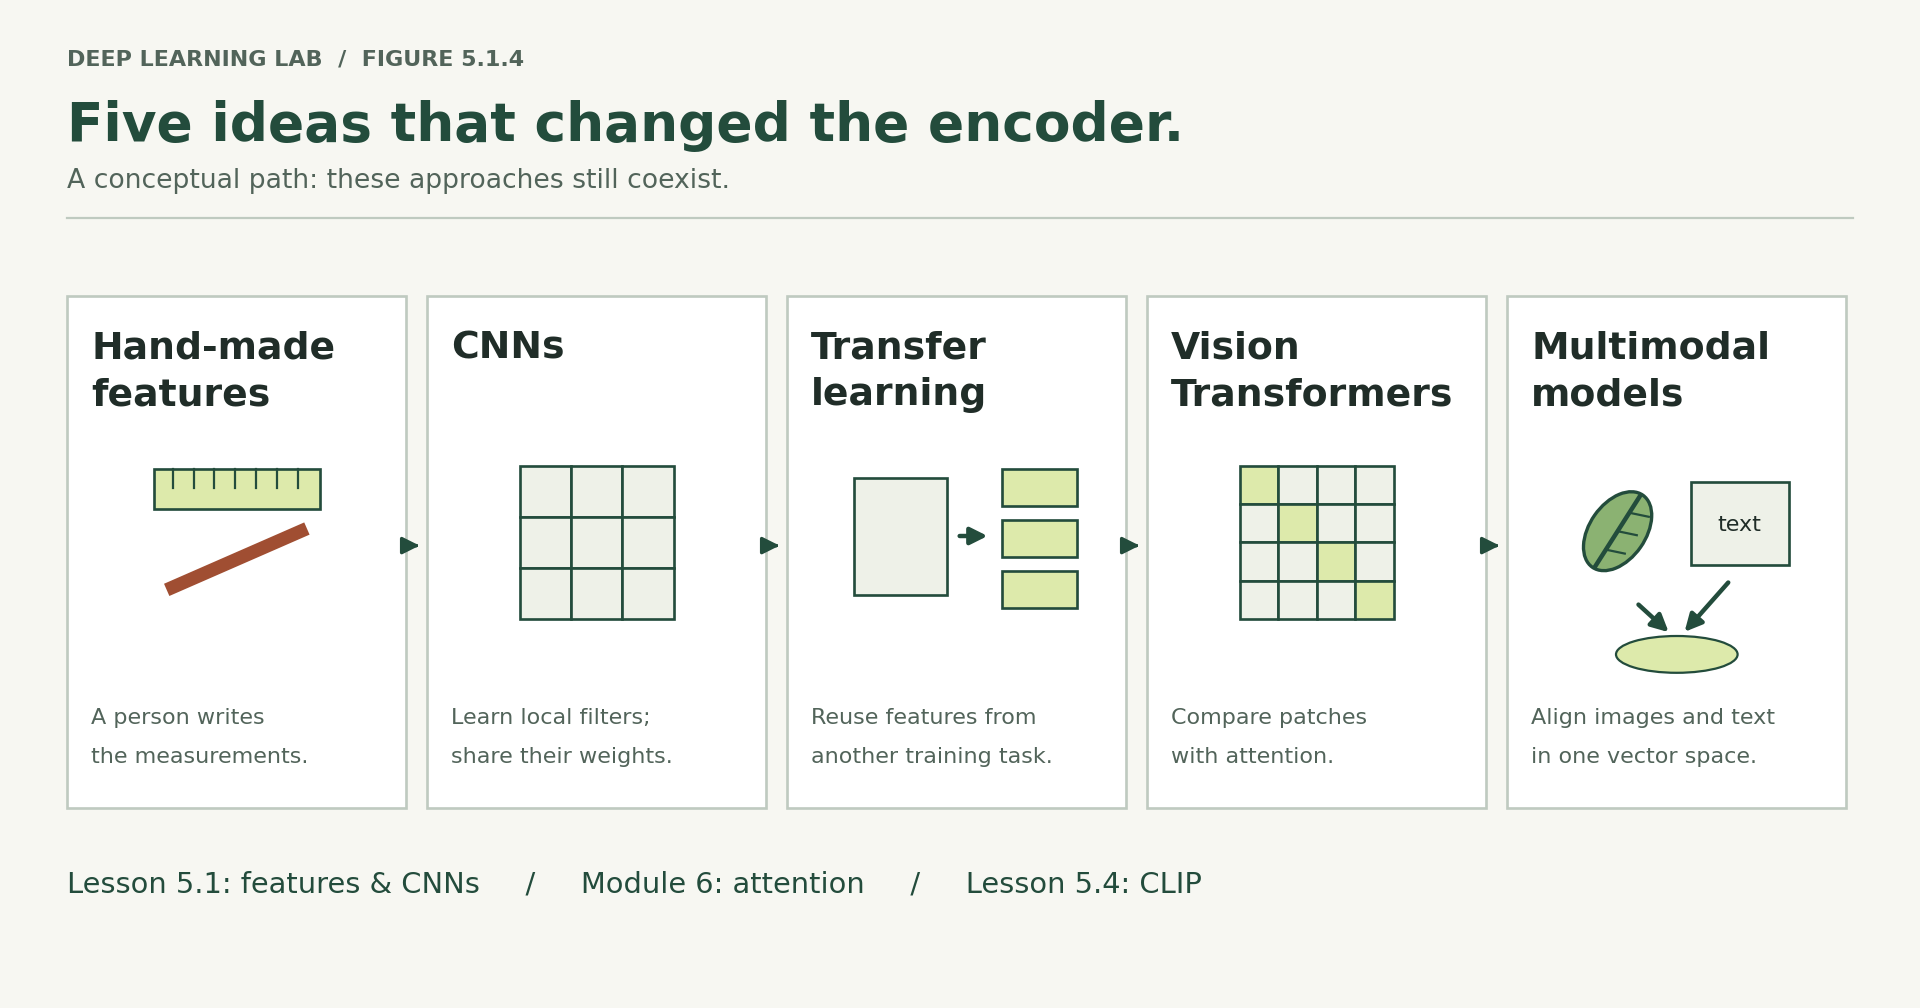

<p><b>Figure 5.1.4.</b> From hand-written measurements to learned and shared representations. The sequence is a learning roadmap, not a claim that newer models replace every older one.</p>

</div>

## 11. What to take away

- A **representation** is the list of numbers a model sees. A model cannot use what the representation throws away.
- The pipeline for the whole day is **raw input → encoder → representation → task**. Representation learning means the encoder is learned, not written.
- **Raw pixels** are a poor representation of a photo: their distances mostly measure layout and lighting, and they change a lot when the leaf simply moves.
- **Hand-made features** can work for one problem, but every new problem needs new human ideas.
- A **convolution** slides a small filter over the photo. Locality and weight sharing make CNNs need thousands of times fewer weights than a fully connected layer on the same input.
- An **untrained** CNN, with 11.7 million random weights, did no better than raw pixels. The design makes learning possible; it is the **learned weights** that make the representation good.
- The same CNN **pretrained** on ImageNet took kNN from 0.5938 to 0.7969, on a task ImageNet never contained. Reusing it like this is **transfer learning**.
- We checked that gain photo by photo with a sign test, the Day 4 habit, before believing it.

### Next: note 5.2 — Text embeddings

Photos have pixels. Text does not: it has words, in an order, of any length. In note 5.2 we take the same idea — a learned encoder that turns raw input into a list of numbers — and apply it to text. You will turn 13,083 real bank-customer questions into lists of numbers called **embeddings**, measure closeness properly with cosine similarity, build a search engine by hand, and find out where these embeddings fool themselves.